# `demo_COMMA2026_jair` — Jiminy Advisor demo (COMMA 2026)

Scenario: `scenarios/demo_COMMA2026_jair.yaml`

This notebook runs the Jiminy Advisor demo scenario with the three stakeholders used across
the examples (**Law**, **Household**, **Manuf**), using the classical two-phase `jiminy`
semantics, and shows the argumentation attack diagram and the reasoning graph.

Active context evaluated: `w1 w2 w3 w4`.


In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

from jiminy.engine import Jiminy
from jiminy.yaml_loader import load_scenario
from jiminy.visualization.argumentation_visualizer import ArgumentationVisualizer

PATH = "../scenarios/demo_COMMA2026_jair.yaml"

def load(path=PATH):
    (pf, norms, contrariness, priorities, context_desc, norm_desc,
     contrariness_desc, priority_desc, base_priorities, meta_priorities) = load_scenario(path)
    return Jiminy(norms, contrariness, priorities, context_desc, norm_desc,
                  contrariness_desc, priority_desc, base_priorities, meta_priorities)


## Load the scenario

In [2]:
jim = load()
print("Facts:", sorted(load_scenario(PATH)[0]))
print("Number of norms:", len(jim.norms))
print("Base priorities:", jim.base_priorities)
print("Meta priorities:", jim.meta_priorities)


[INFO] Base priorities loaded: 3
[INFO] Meta-priority rules loaded: 3
[INFO] Base priorities loaded: 3
[INFO] Meta-priority rules loaded: 3
Facts: ['w1', 'w2', 'w3', 'w4']
Number of norms: 9
Base priorities: {'Law': 5, 'Household': 2, 'Manuf': 1}
Meta priorities: [{'if': 'i_collects_data', 'stakeholder': 'Law', 'value': 4, 'description': 'data collection activates legal authority over manufacturer'}, {'if': 'i_threat', 'stakeholder': 'Law', 'value': 5, 'description': 'threat detection escalates legal authority over all stakeholders'}, {'if': 'i_no_threat', 'stakeholder': 'Household', 'value': 4, 'description': 'in absence of threat, household authority prevails over law'}]


## Compute the two-phase `jiminy` semantics

In [3]:
context = ["w1", "w2", "w3", "w4"]
E, P, O = jim.compute_jiminy(context)
print("E (institutional facts) :", sorted(E))
print("P (permissions)          :", sorted(P))
print("O (obligations)          :", sorted(O))
print()
print("Final recommendation     :", sorted(P | O))
print("Rejected heads           :", sorted({a.hd for a in jim.generate_arguments(context)} - (E | P | O)))


E (institutional facts) : ['i_collects_data', 'i_privacy_context', 'i_registered', 'i_threat', 'w1', 'w2', 'w3', 'w4']
P (permissions)          : ['d_collect_no_consent']
O (obligations)          : ['d_compliant', 'd_report']

Final recommendation     : ['d_collect_no_consent', 'd_compliant', 'd_report']
Rejected heads           : ['d_gdpr', 'd_protect_privacy']


## Narrative explanation

In [4]:
accepted_heads = E | P | O
args = jim.generate_arguments(context)
accepted = [a for a in args if a.hd in accepted_heads]
rejected = [a for a in args if a.hd not in accepted_heads]
print(jim.explain(accepted, rejected, context, semantics="jiminy"))


CONTEXT ANALYSIS
------------------------------------------------------------
 - w1
 - w2
 - w3
 - w4

GENERATED ARGUMENTS
------------------------------------------------------------
 - ('w4',) ⇒ i_registered (Institutional fact, stakeholder=Manuf)
 - ('w2',) ⇒ i_collects_data (Institutional fact, stakeholder=Law)
 - ('w3',) ⇒ i_threat (Institutional fact, stakeholder=Law)
 - ('i_collects_data',) ⇒ i_privacy_context (Institutional fact, stakeholder=Household)
 - ('w1',) ⇒ d_compliant (Obligation, stakeholder=Law)
 - ('i_registered',) ⇒ d_gdpr (Obligation, stakeholder=Law)
 - ('i_collects_data',) ⇒ d_protect_privacy (Obligation, stakeholder=Household)
 - ('i_threat',) ⇒ d_report (Obligation, stakeholder=Household)
 - ('i_threat',) ⇒ d_collect_no_consent (Permission, stakeholder=Manuf)

DETECTED CONFLICTS
------------------------------------------------------------
 - d_compliant conflicts with: d_collect_no_consent
 - d_gdpr conflicts with: d_collect_no_consent
 - d_protect_privacy con

## Argumentation attack diagram (attacks and winners)

Contrariety is symmetric in this scenario, so every contrary pair is drawn as **two red
chi edges (mutual attack)**. Nodes with a **double border** are the winners under the
`jiminy` semantics (`E | P | O`).


[Visualizer] Rendering graph → demo_comma_attack_winners.png


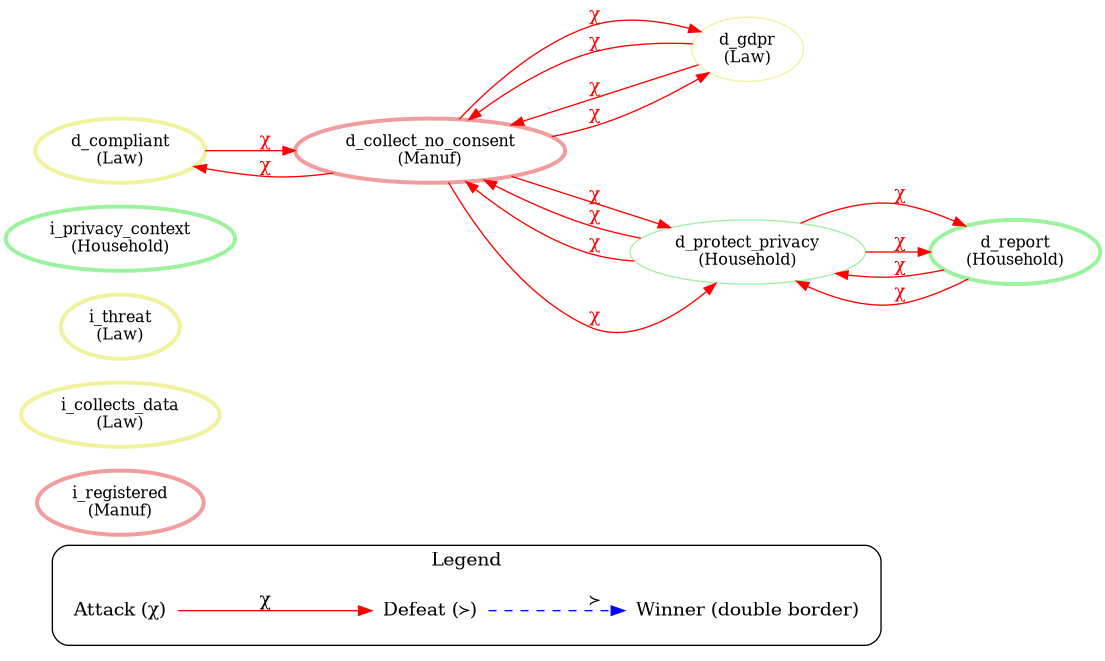

=== Winner heads (accepted) ===
['d_collect_no_consent', 'd_compliant', 'd_report', 'i_collects_data', 'i_privacy_context', 'i_registered', 'i_threat', 'w1', 'w2', 'w3', 'w4']
=== Attack relations (chi) present ===
  d_gdpr  <->  d_collect_no_consent
  d_collect_no_consent  <->  d_gdpr
  d_collect_no_consent  <->  d_protect_privacy
  d_protect_privacy  <->  d_report
  d_protect_privacy  <->  d_collect_no_consent
  d_report  <->  d_protect_privacy
  d_compliant  <->  d_collect_no_consent


In [5]:
from IPython.display import Image, display

args = jim.generate_arguments(context)
accepted_heads = E | P | O
av = ArgumentationVisualizer()
av.build_graph(arguments=args, winners={a.hd for a in args if a.hd in accepted_heads},
               priorities=jim.priorities, contrariness=jim.contrariness)
name = "demo_comma_attack_winners"
av.render(name)
display(Image(filename=f"{name}.png"))

print("=== Winner heads (accepted) ===")
print(sorted(accepted_heads))
print("=== Attack relations (chi) present ===")
for src, contraries in jim.contrariness.items():
    for c in contraries:
        if c in {a.hd for a in args}:
            print(f"  {src}  <->  {c}")


## Graphviz Advanced Exports — Reasoning graph

Reasoning dependency chain: facts (blue) -> institutional facts (green) -> decisions
(orange = accepted, gray = rejected), with the norm descriptions as labels and a color
legend embedded in the graph.


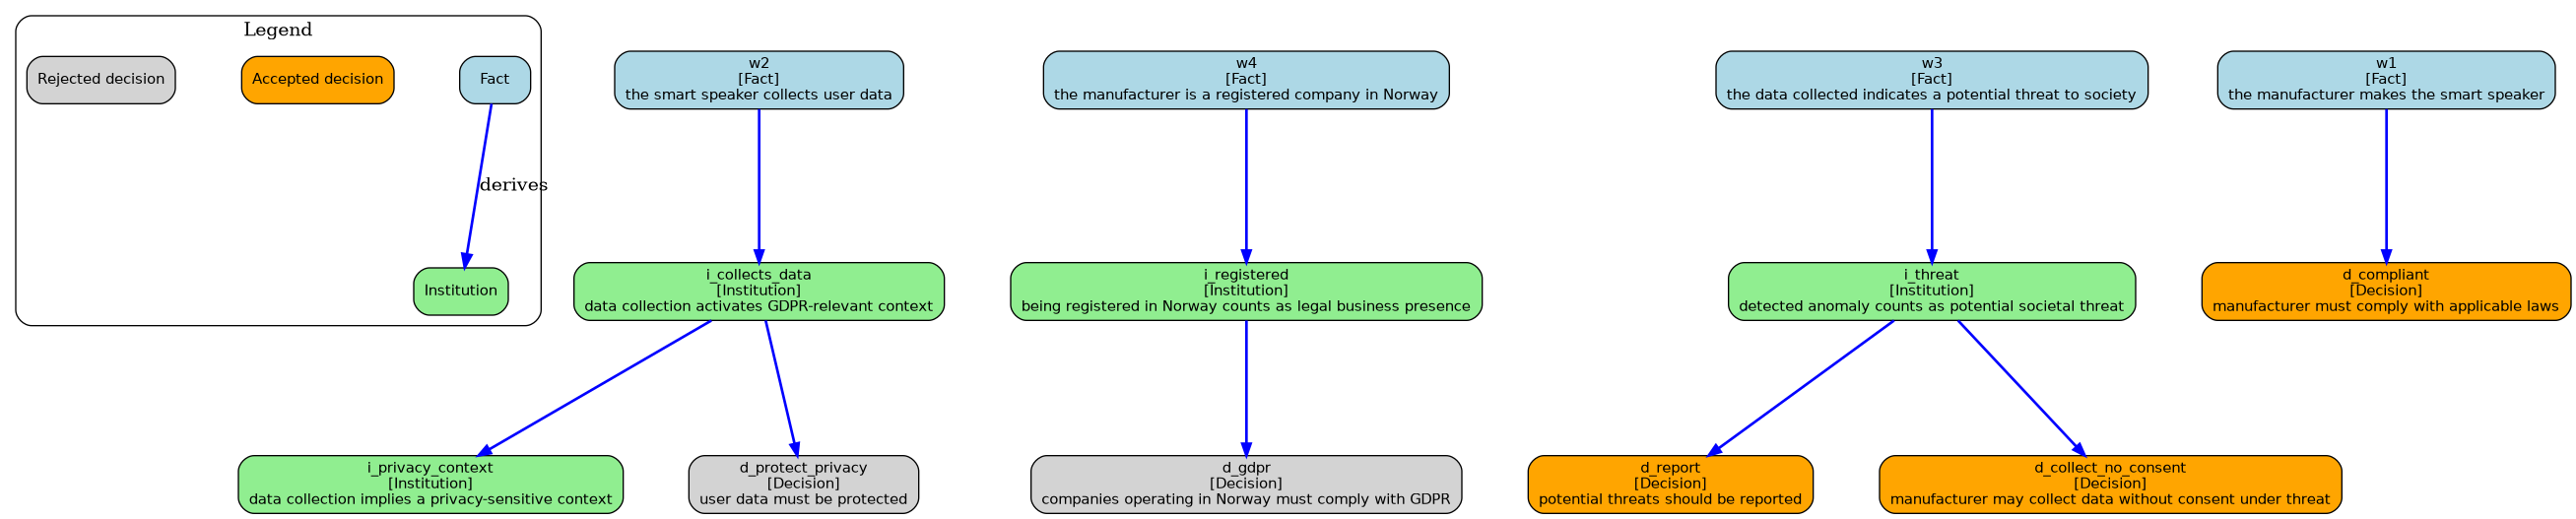

In [6]:
from graphviz import Digraph

def build_label(atom):
    if atom.startswith("w"):
        return f"{atom}\n[Fact]\n{jim.context_desc.get(atom,'')}"
    if atom.startswith("i"):
        return f"{atom}\n[Institution]\n{jim.norm_desc.get(atom,'')}"
    if atom.startswith("d"):
        return f"{atom}\n[Decision]\n{jim.norm_desc.get(atom,'')}"
    return atom

def export_reasoning_graph(path):
    g = Digraph("Jiminy Reasoning", engine="dot")
    g.attr(rankdir="TB", ranksep="1.4", nodesep="0.7", splines="spline")
    g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="11")

    with g.subgraph(name="cluster_legend") as legend:
        legend.attr(label="Legend", style="rounded", color="black", fontsize="14")
        legend.node("lg_fact", "Fact", fillcolor="lightblue")
        legend.node("lg_inst", "Institution", fillcolor="lightgreen")
        legend.node("lg_acc", "Accepted decision", fillcolor="orange")
        legend.node("lg_rej", "Rejected decision", fillcolor="lightgray")
        legend.edge("lg_fact", "lg_inst", color="blue", penwidth="2", label="derives")

    winners = {a.hd for a in accepted}
    facts, inst, decisions = set(), set(), set()
    edges = []
    for a in args_final:
        head = a.hd
        if head.startswith("w"): facts.add(head)
        elif head.startswith("i"): inst.add(head)
        elif head.startswith("d"): decisions.add(head)
        for b in getattr(a.origin_norm, "body", []):
            edges.append((b, head))
            if b.startswith("w"): facts.add(b)
            elif b.startswith("i"): inst.add(b)
            elif b.startswith("d"): decisions.add(b)

    for w in facts: g.node(w, label=build_label(w), fillcolor="lightblue")
    for i in inst: g.node(i, label=build_label(i), fillcolor="lightgreen")
    for d in decisions:
        g.node(d, label=build_label(d), fillcolor="orange" if d in winners else "lightgray")
    for a, b in edges: g.edge(a, b, color="blue", penwidth="2", arrowsize="0.9")

    g.render(path, format="png", cleanup=True)
    return f"{path}.png"

args_final = jim.generate_arguments(context)
winners = {a.hd for a in args_final if a.hd in (E | P | O)}
accepted = [a for a in args_final if a.hd in winners]

display(Image(filename=export_reasoning_graph("demo_comma_reasoning")))


## Comparison: `compute_jiminy` vs `compute_jiminy_bidirectional`

The standard two-phase procedure accepts both the permission `d_collect_no_consent` and the
obligation `d_compliant` even though they attack each other. The **bidirectional** variant
(separate core function, `compute_jiminy` unchanged) also drops a regulative rule whose head
*attacks* an active element, so every attack resolves to a single winner.


In [7]:
E1, P1, O1 = jim.compute_jiminy(context)
E2, P2, O2 = jim.compute_jiminy_bidirectional(context)

print("standard       : O =", sorted(O1), "| P =", sorted(P1))
print("bidirectional  : O =", sorted(O2), "| P =", sorted(P2))
print()
print("d_compliant dropped ->", "d_compliant" in O1 and "d_compliant" not in O2)
print("winner of the attack ->", sorted(P2 | O2))


standard       : O = ['d_compliant', 'd_report'] | P = ['d_collect_no_consent']
bidirectional  : O = ['d_report'] | P = ['d_collect_no_consent']

d_compliant dropped -> True
winner of the attack -> ['d_collect_no_consent', 'd_report']
